## HIV 

## Keras Sequential Model Selection

Multilayer Perceptron

Learning Rate	10^-3

Optimizer =Adam

Regularization= L1, L2

Activation= Tanh

Split= %64, %16, %20

In [ ]:
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation
from keras.optimizers import SGD
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from keras.models import model_from_json
from sklearn.utils import shuffle
from keras import regularizers


#data preperation
df1 = pd.read_csv('/Users/blue/Desktop/HIV/746Data.txt', header=None )
df2 = pd.read_csv('/Users/blue/Desktop/HIV/1625Data.txt', header=None )
df3 = pd.read_csv('/Users/blue/Desktop/HIV/impensData.txt', header=None )
df4 = pd.read_csv('/Users/blue/Desktop/HIV/schillingData.txt', header=None )
frames = [df1, df2, df3, df4] #concatanate all data

HIV = pd.concat(frames).values
#HIV= np.random.shuffle(HIV)

dic={'G':1, 'P':2, 'A':3, 'V':4, 'L':5, 'I':6, 'M':7, 'C':8, 'F':9, 
    'Y':10, 'W':11, 'H':12, 'K':13, 'R':14, 'Q':15, 'N':16, 'E':17,'D':18, 'S':19, 'T':20}
octamer= HIV[:,0]
#print(octamer[0][0])
aa_list=[]
for octamer_value in octamer:
    aa_seq=[]
    for aa in octamer_value:
        if(aa in dic.keys()):
            aa_seq.append(dic[aa])
            
    aa_list.append(aa_seq)
    
#print(aa_list)               
x= pd.DataFrame(aa_list).as_matrix()
print(x.shape)
y= HIV[:,1]
y=pd.get_dummies(y).as_matrix()
print(y.shape)


X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=100)

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=100)
    
    

#X_train, X_val, X_test= x[:3954,:], x[3954:5272,:], x[5272:6590,:]

#y_train, y_val, y_test= y[:3954,9], y[3954:5272,9], y[5272:6590,9]
    
    
print("X_train",X_train.shape)
print("y_train",y_train.shape)
print("X_val",X_val.shape)
print("y_val",y_val.shape)
print("X_test",X_test.shape)
print("y_test",y_test.shape)


In [ ]:
HIV

## No regulation

In [ ]:

""" 2 hidden layer with 8 units 
    input layer= 22
    output layer= 4  
    regularization=
    kernel_regularizer=regularizers.l2(0.01),
    activity_regularizer=regularizers.l1(0.01)
    """

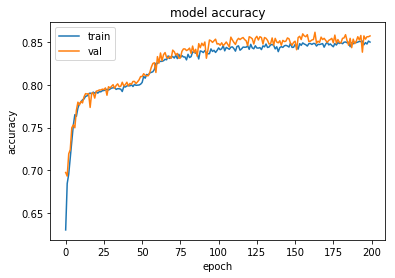

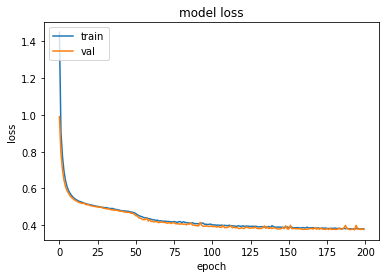

In [ ]:

model = Sequential()
model.add(Dense(7, activation='relu', input_dim=8, kernel_regularizer=regularizers.l2(0.01)))
model.add(Dense(7, activation='relu'))
model.add(Dense(2, activation='sigmoid'))



#compile, configures the model for training.
adam= keras.optimizers.Adam(lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False)
model.compile(loss='binary_crossentropy',
              optimizer=adam,
              metrics=['accuracy'])


#Fit, trains the model for a fixed number of epochs (iterations on a dataset).
history= model.fit(X_train, y_train,
          epochs=200,
          batch_size=100,
          validation_data=(X_val, y_val))


# evaluate the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
scores = model.evaluate(X_train, y_train, verbose=0)
print("Training %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


# evaluate the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
scores= model.evaluate(X_val, y_val, verbose=0)
print("Validation %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


# evaluate the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
scores= model.evaluate(X_test, y_test, verbose=0)
print("Test %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

## Regularization 1

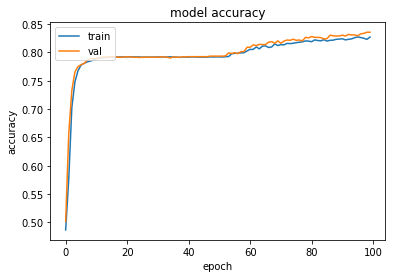

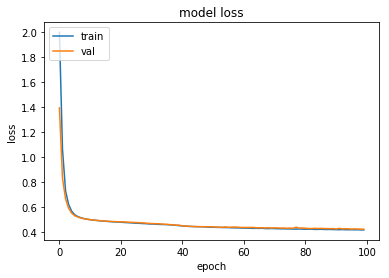

In [ ]:
model = Sequential()
model.add(Dense(7, activation='relu', input_dim=8, ))
Dropout(0.1)
model.add(Dense(7, activation='relu'))
Dropout(0.1)
model.add(Dense(2, activation='sigmoid'))

#compile, configures the model for training.

model.compile(loss='binary_crossentropy',
              optimizer=keras.optimizers.Adam(lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False),
              metrics=['accuracy'])


#Fit, trains the model for a fixed number of epochs (iterations on a dataset).
history= model.fit(X_train, y_train,
          epochs=100,
          batch_size=100,
          validation_data=(X_val, y_val))


# evaluate the model

scores = model.evaluate(X_train, y_train, verbose=0)
print("Training %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


# evaluate the model

scores= model.evaluate(X_val, y_val, verbose=0)
print("Validation %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

# evaluate the model

scores= model.evaluate(X_test, y_test, verbose=0)
print("Test %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))

# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

## Regularization 2

## Regularization 3

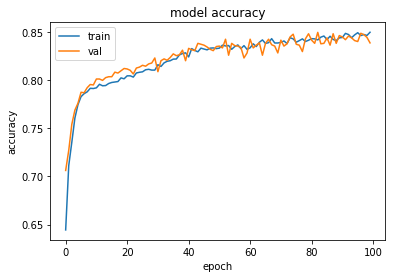

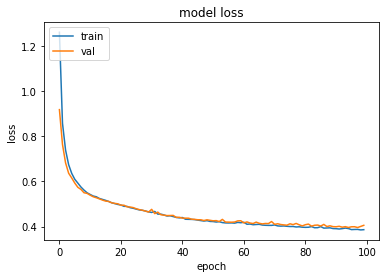

In [ ]:

model = Sequential()
model.add(Dense(13, activation='relu', input_dim=8, kernel_regularizer=regularizers.l2(0.01)))
model.add(Dense(13, activation='relu'))
model.add(Dense(2, activation='sigmoid'))



#compile, configures the model for training.
adam= keras.optimizers.Adam(lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False)
model.compile(loss='binary_crossentropy',
              optimizer=adam,
              metrics=['accuracy'])


#Fit, trains the model for a fixed number of epochs (iterations on a dataset).
history= model.fit(X_train, y_train,
          epochs=100,
          batch_size=100,
          validation_data=(X_val, y_val))


# evaluate the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
scores = model.evaluate(X_train, y_train, verbose=0)
print("Training %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


# evaluate the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
scores= model.evaluate(X_val, y_val, verbose=0)
print("Validation %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


# evaluate the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
scores= model.evaluate(X_test, y_test, verbose=0)
print("Test %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

## REgulariztion 3

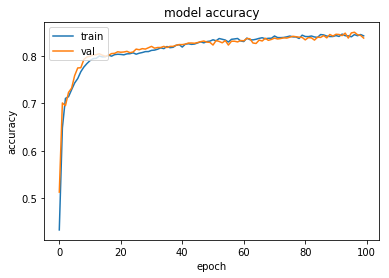

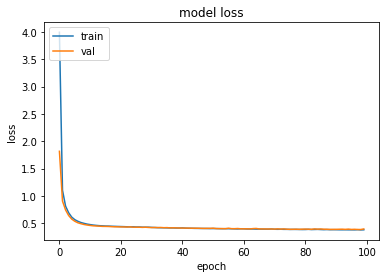

In [ ]:

model = Sequential()
model.add(Dense(13, activation='relu', input_dim=8, ))
Dropout(0.1)
model.add(Dense(13, activation='relu'))
model.add(Dense(2, activation='sigmoid'))



#compile, configures the model for training.
adam= keras.optimizers.Adam(lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False)
model.compile(loss='binary_crossentropy',
              optimizer=adam,
              metrics=['accuracy'])


#Fit, trains the model for a fixed number of epochs (iterations on a dataset).
history= model.fit(X_train, y_train,
          epochs=100,
          batch_size=100,
          validation_data=(X_val, y_val))


# evaluate the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
scores = model.evaluate(X_train, y_train, verbose=0)
print("Training %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


# evaluate the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
scores= model.evaluate(X_val, y_val, verbose=0)
print("Validation %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


# evaluate the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
scores= model.evaluate(X_test, y_test, verbose=0)
print("Test %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

## Regularization 4

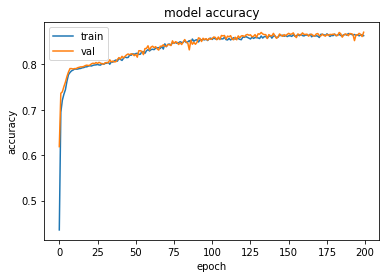

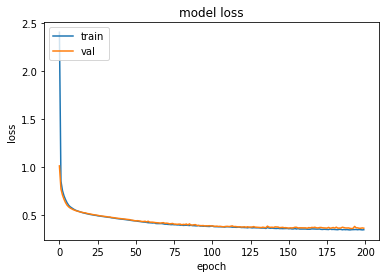

In [ ]:

model = Sequential()
model.add(Dense(13, activation='relu', input_dim=8, kernel_regularizer=regularizers.l2(0.01)))
Dropout(0.1)
model.add(Dense(13, activation='relu'))
model.add(Dense(2, activation='sigmoid'))



#compile, configures the model for training.
adam= keras.optimizers.Adam(lr=0.001, beta_1=0.9, beta_2=0.999, epsilon=None, decay=0.0, amsgrad=False)
model.compile(loss='binary_crossentropy',
              optimizer=adam,
              metrics=['accuracy'])


#Fit, trains the model for a fixed number of epochs (iterations on a dataset).
history= model.fit(X_train, y_train,
          epochs=200,
          batch_size=100,
          validation_data=(X_val, y_val))


# evaluate the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
scores = model.evaluate(X_train, y_train, verbose=0)
print("Training %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


# evaluate the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
scores= model.evaluate(X_val, y_val, verbose=0)
print("Validation %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


# evaluate the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])
scores= model.evaluate(X_test, y_test, verbose=0)
print("Test %s: %.2f%%" % (model.metrics_names[1], scores[1]*100))


# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()